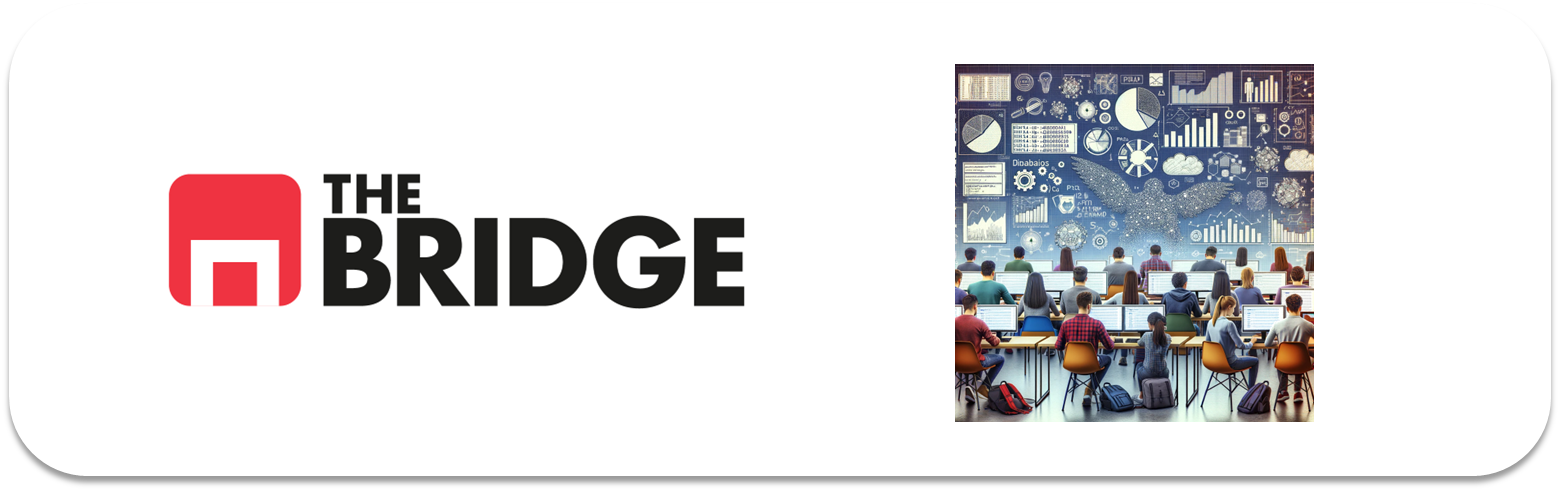

## PRACTICA OBLIGATORIA: **Clasificacion y Regresion Logistica**

* La práctica obligatoria de esta unidad consiste en modelar la supervivencia en el Titanic, por fin, además de una parte adicional multiclase. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

### Indicaciones

A continuación tienes las indicaciones para hacer el modelado. No necesariamente tienes que seguirlos al pie de la letra, porque a partir de ahora ya las práctica obligatorias dejarán de ser mayormente guiadas por ejercicios y serán más de libre desarrollo, aunque con objetivos específicos, claros y determinados. 

En concreto se pide hacer un modelo de regresión logística, evaluarlo contra un dataset de test reservado del original mostrando las métricas propias de los problemas de clasificación, la matriz de confusión y la curva ROC. Además se pide comparar las predicciones con los valores reales y al final adaptar el modelo a un problema multiclase.

Los pasos para guiar el trabajo:
1. Carga el dataset del Titanic. 
2. Deshazte de las variables que no vayas a usar. Limpia lo que creas necesarios pero no hagas imputaciones.
3. Escoge y analiza la variable target de forma gráfica y razona sobre el impacto de la distribución en los resultados esperados. Ten en cuenta que lo que queremos es poder predecir si un pasajero sobrevivirá.
4. Haz el split en train y test que creas conveniente pero asegurándote que ambos conjuntos tienen un reparto similar de pasajeros embarcados en las tres ciudades.
5. Construye las parejas X,y de train y test.
6. Ahora sí imputa los nulos con medias y modas en la X de train. Guarda esas medias que necesitarás en la parte de test.
7. Haz un mini-EDA, selecciona las features que quieres quedarte y por qué.
8. Trata las variables para que funcionen lo mejor posible en el modelo.
9. Construye un modelo de regresión logística.
10. EXTRA: Analiza si lo crees conveniente los pesos y la importancia de las features.
11. Procesa el dataset de Test para que puedas usarlo en la evaluación 
12. Evalúa tu modelo contra el dataset de test y train. Obten las matrices de confusión y las métricas que creas adecuadas. Haz un pequeño assesment de su generabilidad.
13. EXTRA: Halla la probabilidad de supervivencia de un hombre de entre 30 y 40 años, que embarcó en Southampton en segunda clase, viajaba solo y no pagó el billete. PISTA: En este caso tendrás que calcular varias probabilidades y hacer la media de ellas.
14. EXTRA: Aprovecha todo el trabajo haciendo un único cambio en el target, ahora será la clase del viajero. Cambia el target quitándolo de X_train, X_test y añade a estos el target anterior. El resto no deberías cambiarlo. Entrena y evalua el modelo sólo con el classification_report.  



---
## Solución

### 0-1. Imports y carga del dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, roc_curve, auc

pd.options.mode.copy_on_write = True

df = pd.read_csv("./data/titanic.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### 2. Target y limpieza inicial
Descartamos variables redundantes o derivadas (`embark_town`, `alive`, `class`, `adult_male`).

In [2]:
target = "survived"
excluidas = ["embark_town", "alive", "class", "adult_male"]
df = df.drop(columns=excluidas)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   who       891 non-null    object 
 9   deck      203 non-null    object 
 10  alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 70.6+ KB


### 3. Análisis del target

survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


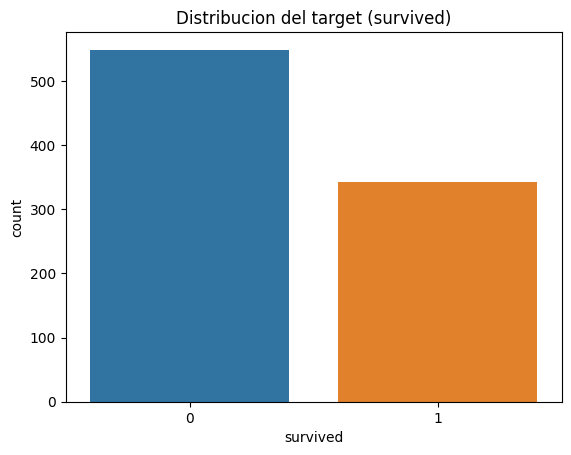

In [3]:
print(df[target].value_counts(normalize=True))
sns.countplot(x=target, data=df, hue=target, legend=False)
plt.title("Distribucion del target (survived)")
plt.show()

El target está **ligeramente desbalanceado** (~62% no sobrevive / ~38% sí). No es extremo, pero conviene fijarse en *precision*/*recall* por clase y no solo en el *accuracy*.

### 4. Tratamiento previo y split estratificado por `embarked`
`deck` tiene muchos nulos → la convertimos en binaria `deck_informed`. `embarked` tiene 2 nulos → eliminamos esas filas para poder estratificar.

In [4]:
df["deck_informed"] = df["deck"].notna().astype(int)
df = df.drop(columns=["deck"])

print("Nulos en embarked:", df["embarked"].isna().sum())
df = df.dropna(subset=["embarked"])

train_set, test_set = train_test_split(df, test_size=0.2, stratify=df["embarked"], random_state=42)
print("Train:", train_set.shape, "| Test:", test_set.shape)
print("\nReparto embarked TRAIN:\n", train_set["embarked"].value_counts(normalize=True))
print("\nReparto embarked TEST:\n", test_set["embarked"].value_counts(normalize=True))

Nulos en embarked: 2
Train: (711, 11) | Test: (178, 11)

Reparto embarked TRAIN:
 embarked
S    0.724332
C    0.188467
Q    0.087201
Name: proportion, dtype: float64

Reparto embarked TEST:
 embarked
S    0.724719
C    0.191011
Q    0.084270
Name: proportion, dtype: float64


### 6. Imputación de nulos (`age`) con estadísticos de TRAIN
Imputamos la edad por la **mediana** según el grupo `who` (man/woman/child), calculada **solo con train** y aplicada también a test.

In [5]:
medianas = train_set.groupby("who")["age"].median()
print("Medianas de edad por grupo (train):\n", medianas)

for grupo, mediana in medianas.items():
    train_set.loc[(train_set["who"] == grupo) & (train_set["age"].isna()), "age"] = mediana
    test_set.loc[(test_set["who"] == grupo) & (test_set["age"].isna()), "age"] = mediana

print("\nNulos restantes -> train:", int(train_set["age"].isna().sum()), "| test:", int(test_set["age"].isna().sum()))

Medianas de edad por grupo (train):
 who
child     5.0
man      30.0
woman    30.0
Name: age, dtype: float64

Nulos restantes -> train: 0 | test: 0


### 7. Mini-EDA y selección de features

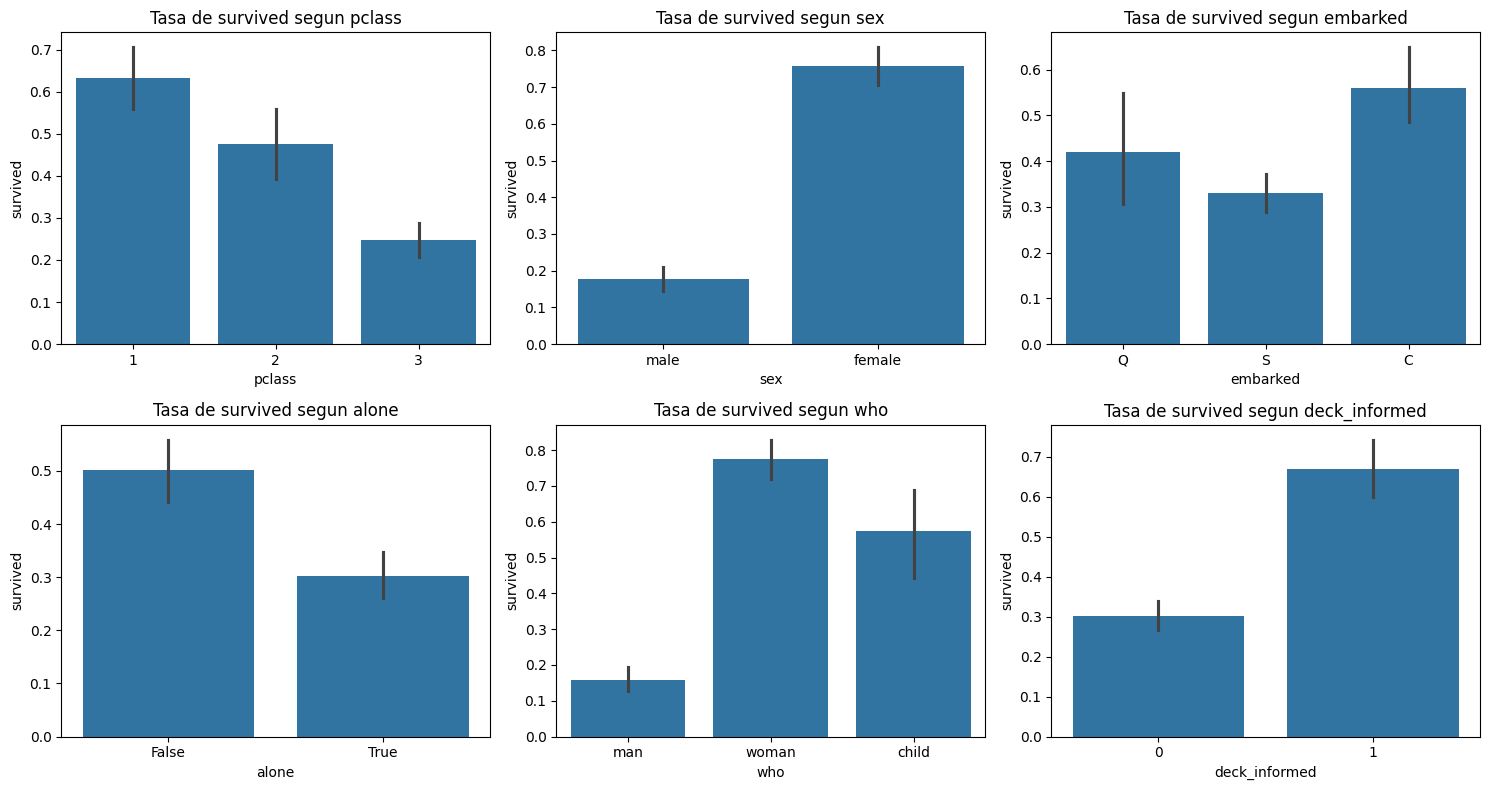

In [6]:
features_cat = ["pclass", "sex", "embarked", "alone", "who", "deck_informed"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.ravel(), features_cat):
    sns.barplot(x=feat, y=target, data=train_set, ax=ax)
    ax.set_title(f"Tasa de {target} segun {feat}")
plt.tight_layout()
plt.show()

`pclass`, `sex`/`who`, `embarked`, `alone` y `deck_informed` muestran diferencias claras en la tasa de supervivencia → las mantenemos. De las numéricas usamos `age`, `sibsp` y `fare`.

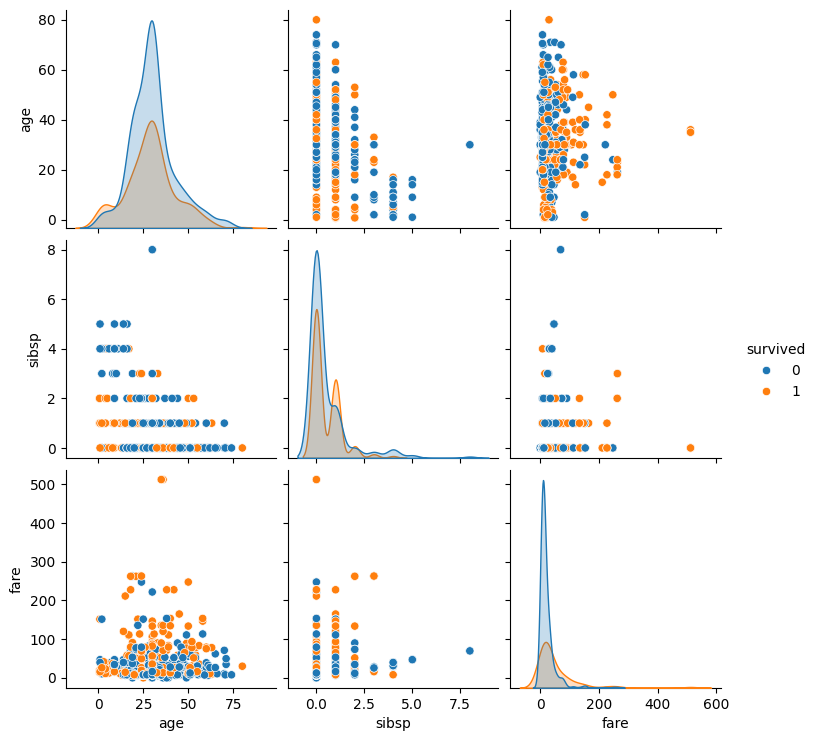

In [7]:
features_num = ["age", "sibsp", "fare"]
sns.pairplot(train_set[features_num + [target]], hue=target)
plt.show()

### 8. Tratamiento de variables (encoding + transformación + escalado)

In [8]:
# 'alone' booleana -> int
train_set["alone"] = train_set["alone"].astype(int)
test_set["alone"] = test_set["alone"].astype(int)

# Ordinal encoding de las categoricas de texto
cat_text = ["sex", "embarked", "who"]
categories = [["female", "male"], ["S", "C", "Q"], ["child", "woman", "man"]]
encoder = OrdinalEncoder(categories=categories)
train_set[cat_text] = encoder.fit_transform(train_set[cat_text])
test_set[cat_text] = encoder.transform(test_set[cat_text])

# 'fare' muy sesgada -> raiz cuadrada
train_set["fare"] = np.sqrt(train_set["fare"])
test_set["fare"] = np.sqrt(test_set["fare"])

# Escalado de las numericas (fit solo en train)
scaler = StandardScaler()
train_set[features_num] = scaler.fit_transform(train_set[features_num])
test_set[features_num] = scaler.transform(test_set[features_num])
train_set[features_cat + features_num].head()

,pclass,sex,embarked,alone,who,deck_informed,age,sibsp,fare
46,3,1.0,2.0,0,2.0,0,0.017902,0.510583,-0.286239
230,1,0.0,0.0,0,1.0,1,0.401485,0.510583,1.470612
657,3,0.0,2.0,0,1.0,0,0.171335,0.510583,-0.286239
888,3,0.0,0.0,0,1.0,0,0.017902,0.510583,0.019727
809,1,0.0,0.0,0,1.0,1,0.248052,0.510583,0.845686


### 9. Modelo de regresión logística

In [9]:
features_model = features_cat + features_num
X_train, y_train = train_set[features_model], train_set[target]
X_test, y_test = test_set[features_model], test_set[target]

log_class = LogisticRegression(max_iter=10000)
log_class.fit(X_train, y_train)
print("Modelo entrenado con features:", features_model)

Modelo entrenado con features: ['pclass', 'sex', 'embarked', 'alone', 'who', 'deck_informed', 'age', 'sibsp', 'fare']


### 10. EXTRA: pesos / importancia de las features

                   coef
sex           -1.528855
who           -1.262323
pclass        -0.755286
sibsp         -0.637033
age           -0.130182
alone         -0.075032
fare           0.221985
embarked       0.264170
deck_informed  0.290277


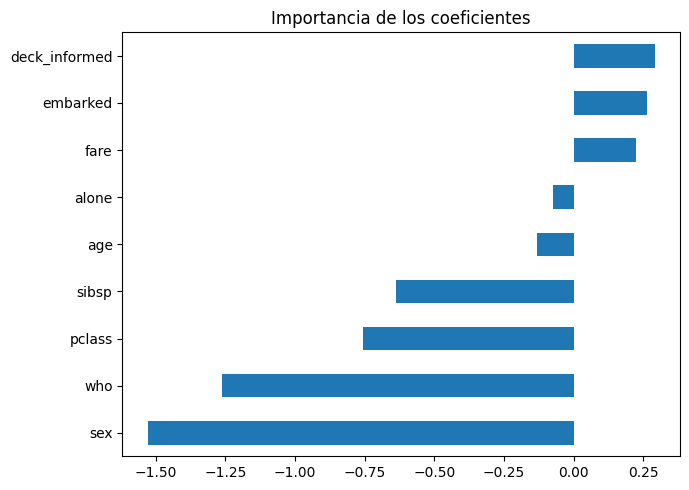

In [10]:
coef_df = pd.DataFrame(log_class.coef_[0], index=log_class.feature_names_in_, columns=["coef"]).sort_values("coef")
print(coef_df)
coef_df.plot(kind="barh", legend=False, figsize=(7, 5))
plt.title("Importancia de los coeficientes")
plt.tight_layout()
plt.show()

### 11-12. Evaluación contra train y test (matriz de confusión + métricas + ROC)

===== TRAIN =====


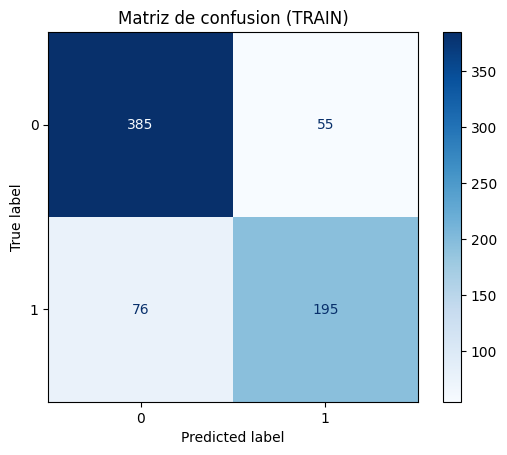

              precision    recall  f1-score   support

           0       0.84      0.88      0.85       440
           1       0.78      0.72      0.75       271

    accuracy                           0.82       711
   macro avg       0.81      0.80      0.80       711
weighted avg       0.81      0.82      0.81       711

===== TEST =====


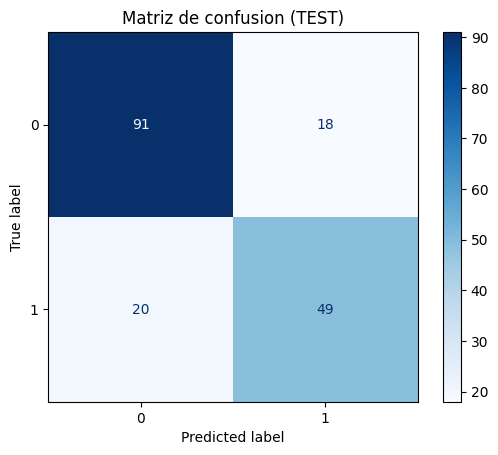

              precision    recall  f1-score   support

           0       0.82      0.83      0.83       109
           1       0.73      0.71      0.72        69

    accuracy                           0.79       178
   macro avg       0.78      0.77      0.77       178
weighted avg       0.79      0.79      0.79       178



In [11]:
def metrics_titanic(model, X, y, nombre):
    pred = model.predict(X)
    print(f"===== {nombre} =====")
    ConfusionMatrixDisplay.from_predictions(y, pred, cmap="Blues")
    plt.title(f"Matriz de confusion ({nombre})")
    plt.show()
    print(classification_report(y, pred))

metrics_titanic(log_class, X_train, y_train, "TRAIN")
metrics_titanic(log_class, X_test, y_test, "TEST")

AUROC: 0.861


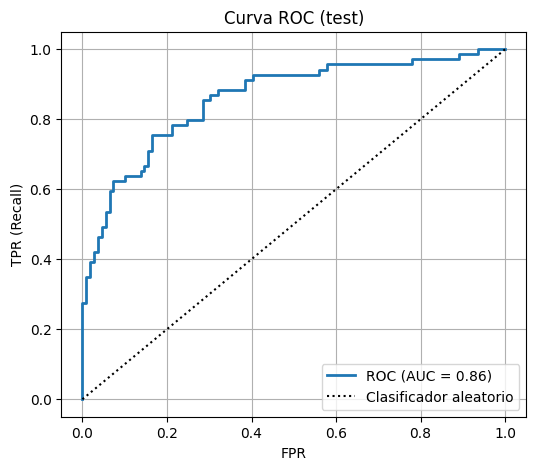

In [12]:
scores = log_class.predict_proba(X_test)[:, 1]
fpr, tpr, thr = roc_curve(y_test, scores)
roc_auc = auc(fpr, tpr)
print("AUROC:", round(roc_auc, 3))
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:0.2f})")
plt.plot([0, 1], [0, 1], 'k:', label="Clasificador aleatorio")
plt.xlabel("FPR"); plt.ylabel("TPR (Recall)")
plt.title("Curva ROC (test)"); plt.legend(loc="lower right"); plt.grid()
plt.show()

Las métricas de **train** y **test** son muy similares (accuracy y AUC parecidos), por lo que el modelo **generaliza bien** y no hay sobreajuste apreciable.

### 13. EXTRA: probabilidad de supervivencia de un caso concreto
Hombre de 30-40 años, embarcado en Southampton, 2ª clase, viaja solo y no pagó billete. Promediamos la probabilidad para cada edad de 30 a 40.

In [13]:
data_base = {"pclass": 2, "sex": 1, "embarked": 0, "alone": 1, "who": 2,
             "deck_informed": 0, "sibsp": 0, "fare": 0.0}
probs = []
for age in range(30, 41):
    fila = data_base.copy()
    fila["age"] = age
    X_caso = pd.DataFrame([fila])
    # mismas transformaciones que en el entrenamiento: sqrt en fare + escalado
    X_caso["fare"] = np.sqrt(X_caso["fare"])
    X_caso[features_num] = scaler.transform(X_caso[features_num])
    probs.append(log_class.predict_proba(X_caso[features_model])[0][1])
print("Probabilidad media de sobrevivir (30-40 anios):", round(np.mean(probs), 4))

Probabilidad media de sobrevivir (30-40 anios): 0.1387


### 14. EXTRA: versión multiclase (predecir la clase del pasajero `pclass`)
Reutilizamos todo cambiando el target a `pclass` (3 clases): lo quitamos de las features y añadimos `survived`.

In [14]:
new_target = "pclass"
new_features = [f for f in features_model if f != new_target] + [target]
print("Features:", new_features)

Xm_train, ym_train = train_set[new_features], train_set[new_target]
Xm_test, ym_test = test_set[new_features], test_set[new_target]

log_multi = LogisticRegression(max_iter=10000)
log_multi.fit(Xm_train, ym_train)
print("=== TRAIN ===")
print(classification_report(ym_train, log_multi.predict(Xm_train)))
print("=== TEST ===")
print(classification_report(ym_test, log_multi.predict(Xm_test)))

Features: ['sex', 'embarked', 'alone', 'who', 'deck_informed', 'age', 'sibsp', 'fare', 'survived']
=== TRAIN ===
              precision    recall  f1-score   support

           1       0.92      0.90      0.91       163
           2       0.78      0.43      0.55       143
           3       0.82      0.95      0.88       405

    accuracy                           0.84       711
   macro avg       0.84      0.76      0.78       711
weighted avg       0.83      0.84      0.82       711

=== TEST ===
              precision    recall  f1-score   support

           1       0.90      0.92      0.91        51
           2       0.61      0.27      0.37        41
           3       0.74      0.93      0.82        86

    accuracy                           0.78       178
   macro avg       0.75      0.71      0.70       178
weighted avg       0.76      0.78      0.75       178



### Conclusiones

El modelo de **regresión logística** clasifica la supervivencia en el Titanic con buen rendimiento y **generaliza bien** (métricas de test ≈ train, AUC alto). Las variables más influyentes son el **sexo/`who`**, la **clase (`pclass`)** y `fare`, coherente con el "mujeres y niños primero" y el efecto de la clase social.

En la versión **multiclase** (predecir `pclass`), el modelo funciona razonablemente para 1ª y 3ª clase, y peor para 2ª (la más solapada con las otras), como suele ocurrir con la clase intermedia.